# Imports

In [79]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as ss

# Funções

In [80]:
def cramer_v( x, y ): 
    cm = pd.crosstab( x, y ).values
    n = cm.sum() 
    r, k = cm.shape 
    chi2 = ss.chi2_contingency( cm )[0] 
    chi2corr = max( 0, chi2 - (k-1)*(r-1)/(n-1) ) 
    kcorr = k - (k-1)**2/(n-1) 
    rcorr = r - (r-1)**2/(n-1) 

    return np.sqrt((chi2corr/n)/( min( kcorr-1, rcorr-1)))

# Loading Dataset

In [2]:
df = pd.read_excel('dataset/dataset_leite_realista.xlsx')

# Analisando os Dados

In [3]:
df.head().T

drop = ['index', 'Breed', 'Country', 'Climate_Zone', 'Management_System', 'Feed_Type', 'Feeding_Frequency', 'FMD_Vaccine', 'Brucellosis_Vaccine', 'Lot_ID', 'Milking_Interval_hrs', 'Grazing_Duration_hrs', 'Farm_ID', 'Housing_Score']

nome coluna: Health_Event_Day

mudança: Eu recomendaria Days_In_Health_Event: 0 para animais saudáveis e 1, 2, 3... durante o episódio. Isso fica mais intuitivo e evita usar -1.

In [4]:
#ajustando alguns dados e colunas
df1 = df.copy()

df1 = df1.rename(columns=({
    'Days_Since_Health_Event': 'Health_Event_Day'
}))

#df['sexo'] = df['sexo'].map({'M': 'Macho', 'F': 'Fêmea'})
#df['peso_kg'] = df['peso_lb'].map(lambda x: x * 0.453592)

df1['Health_Event_Day'] = df1['Health_Event_Day'].map(lambda x: x + 1)
df1['Heat_Stress_Level'] = df1['Heat_Stress_Level'].map(lambda x: 'Without' if pd.isna(x) else x)

df2 = df1.drop(drop, axis=1)
df2.head().T

,0,1,2,3,4
Cattle_ID,CATTLE_0001,CATTLE_0002,CATTLE_0003,CATTLE_0004,CATTLE_0005
Age_Months,58.6,80.7,50.8,88.6,57.2
Weight_kg,648.7,633.7,644.5,567.7,653.4
Parity,3,5,3,5,3
Lactation_Stage,Early,Early,Early,Early,Mid
Days_in_Milk,50,55,20,81,137
Feed_Quantity_kg,25.85,22.88,22.72,20.29,22.39
Water_Intake_L,69.0,72.8,64.6,56.2,72.7
Walking_Distance_km,1.39,0.59,0.54,0.8,0.41
Rumination_Time_hrs,8.56,7.99,7.64,7.79,7.75


In [5]:
df2.dtypes

Cattle_ID                                str
Age_Months                           float64
Weight_kg                            float64
Parity                                 int64
Lactation_Stage                          str
Days_in_Milk                           int64
Feed_Quantity_kg                     float64
Water_Intake_L                       float64
Walking_Distance_km                  float64
Rumination_Time_hrs                  float64
Resting_Hours                        float64
Ambient_Temperature_C                float64
Humidity_percent                     float64
Temperature_Humidity_Index           float64
Heat_Stress_Level                        str
Season                                   str
Previous_Week_Avg_Yield              float64
Body_Condition_Score                 float64
Body_Condition_Class                     str
Milking_Frequency_per_day              int64
Health_Status                            str
Health_Event_Day                       int64
Date      

In [6]:
#conferindo celulas vazias e duplicadas
df2.isna().sum()

df2.duplicated().sum()


np.int64(0)

# Análise Descritiva

### Variáveis Númericas

In [7]:
num_atributos = df2.select_dtypes(include=['float64', 'int'])
num_atributos.T

,0,1,2,3,4,5,6,7,8,9,...,16550,16551,16552,16553,16554,16555,16556,16557,16558,16559
Age_Months,58.60,80.70,50.80,88.60,57.20,30.90,45.20,72.60,57.20,33.70,...,58.70,45.20,37.10,57.50,64.20,33.70,48.90,101.70,46.50,35.70
Weight_kg,648.70,633.70,644.50,567.70,653.40,598.30,583.20,657.60,636.00,580.60,...,625.80,627.60,677.10,542.90,735.80,595.50,622.40,664.60,654.50,645.50
Parity,3.00,5.00,3.00,5.00,3.00,1.00,2.00,4.00,3.00,1.00,...,3.00,2.00,1.00,3.00,3.00,1.00,2.00,6.00,2.00,1.00
Days_in_Milk,50.00,55.00,20.00,81.00,137.00,35.00,86.00,108.00,92.00,200.00,...,160.00,132.00,272.00,205.00,230.00,195.00,280.00,286.00,273.00,208.00
Feed_Quantity_kg,25.85,22.88,22.72,20.29,22.39,21.74,23.28,25.48,22.37,18.78,...,22.53,23.26,20.27,19.85,22.02,20.14,18.53,21.15,23.03,21.79
Water_Intake_L,69.00,72.80,64.60,56.20,72.70,61.20,65.10,81.00,67.50,57.10,...,69.70,65.80,56.20,58.80,68.10,54.70,68.70,64.00,73.50,51.90
Walking_Distance_km,1.39,0.59,0.54,0.80,0.41,1.82,0.84,0.27,1.13,1.28,...,1.23,1.22,0.68,1.05,0.89,1.15,1.54,0.87,0.56,1.25
Rumination_Time_hrs,8.56,7.99,7.64,7.79,7.75,7.81,8.16,8.33,7.45,7.57,...,8.17,7.64,6.87,8.13,7.85,6.88,7.79,7.83,7.74,6.93
Resting_Hours,10.16,10.67,11.40,11.21,10.21,10.77,10.61,11.34,12.52,10.99,...,10.08,9.69,12.98,12.06,10.80,11.43,9.67,10.40,12.14,11.82
Ambient_Temperature_C,21.70,21.70,21.70,21.70,21.70,21.70,21.70,21.70,21.70,21.70,...,22.40,22.40,22.40,22.40,22.40,22.40,22.40,22.40,22.40,22.40


In [8]:
#tendencia central - média e mediana

ct1 = pd.DataFrame(num_atributos.mean()).T

ct2 = pd.DataFrame(num_atributos.median()).T

#dispersão: std, minimo, maximo, range, skewness, kurtosis

d1 = pd.DataFrame(num_atributos.std()).T
d2 = pd.DataFrame(num_atributos.min()).T
d3 = pd.DataFrame(num_atributos.max()).T
d4 = pd.DataFrame(num_atributos.max() - num_atributos.min()).T
d5 = pd.DataFrame(num_atributos.skew()).T
d6 = pd.DataFrame(num_atributos.kurtosis()).T

#concatenar os resultados
m = pd.concat([ct1, ct2, d1, d2, d3, d4, d5, d6], axis=0).T.reset_index()

#trocando nome das colunas
m.columns = ['atributos', 'mean', 'median', 'std', 'min', 'max', 'range', 'skew', 'kurtosis']
m

#skew:
#-0.5 a 0.5: pouco assimetria
#-1 a -0,5: assimetrica moderadamente
#0.5 a 1: assimetrica moderadamente
#-1 < e > 1: assimetria forte

,atributos,mean,median,std,min,max,range,skew,kurtosis
0,Age_Months,58.413098,57.40,21.414794,26.10,108.00,81.90,0.416151,-0.870700
1,Weight_kg,628.367107,628.50,46.169528,514.10,782.30,268.20,0.304317,0.140251
2,Parity,2.950000,3.00,1.582153,1.00,6.00,5.00,0.410528,-0.926091
3,Days_in_Milk,155.344444,154.00,64.064432,15.00,304.00,289.00,0.050369,-0.917457
4,Feed_Quantity_kg,21.427061,21.45,2.022034,11.90,28.47,16.57,-0.023744,-0.138966
5,Water_Intake_L,65.915731,65.90,8.837383,35.00,97.20,62.20,-0.002431,-0.118315
6,Walking_Distance_km,0.846859,0.85,0.319206,0.10,2.08,1.98,0.045738,-0.176712
7,Rumination_Time_hrs,7.649131,7.65,0.445249,5.47,9.20,3.73,-0.072699,0.099017
8,Resting_Hours,11.186913,11.19,0.845800,7.90,13.50,5.60,-0.048323,-0.065753
9,Ambient_Temperature_C,23.210870,23.25,1.768156,18.60,27.40,8.80,0.010756,-0.389055


### Variáveis Categóricas

In [9]:
cat_atributos = df2.select_dtypes(exclude=['float64', 'int', 'datetime64'])
cat_atributos.T
print(cat_atributos.columns)

Index(['Cattle_ID', 'Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status'],
      dtype='str')


In [10]:
ct3 = cat_atributos.nunique()
ct3

Cattle_ID               180
Lactation_Stage           3
Heat_Stress_Level         3
Season                    2
Body_Condition_Class      3
Health_Status             5
dtype: int64

# Hipóteses

1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio
2. Vacas com idade mediana produz mais leite que as demais faixas de idade
3. Vacas mais pesadas tendem a produzir mais leite
4. Vacas com número de partos mediano produz mais leite que as demais faixas de numero de partos
5. Vacas que ingerem mais águas produzem mais litros leite diários
6. Vacas que andam mais, produzem menos litros de leite diários
7. Vacas que descansam mais tem mais produtividade litros de leite diários
8. Vacas no outono produzem mais litros de leite diariamente
9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite
10. Vacas com score corporal 3 tendem a ter maior produtividade diária
11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária
12. Vacas saudáveis tendem a produzir mais litros de leite 

# E.D.A

### Análise Univariada

#### Variável Resposta

<Axes: xlabel='Milk_Yield_L', ylabel='Count'>

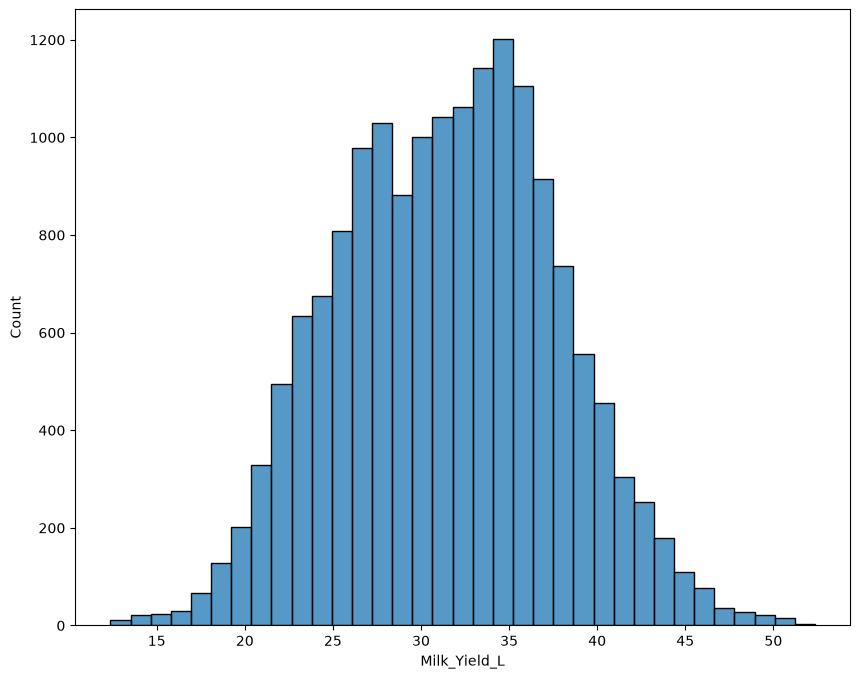

In [11]:
#estudo da variável resposta espsota que é variável contínua

plt.figure(figsize=(10,8))

#gráfico que plota a variável respsota
sns.histplot(df2['Milk_Yield_L'], bins=35)

#### Variáveis Numéricas

array([[<Axes: title={'center': 'Age_Months'}>,
        <Axes: title={'center': 'Weight_kg'}>,
        <Axes: title={'center': 'Parity'}>,
        <Axes: title={'center': 'Days_in_Milk'}>],
       [<Axes: title={'center': 'Feed_Quantity_kg'}>,
        <Axes: title={'center': 'Water_Intake_L'}>,
        <Axes: title={'center': 'Walking_Distance_km'}>,
        <Axes: title={'center': 'Rumination_Time_hrs'}>],
       [<Axes: title={'center': 'Resting_Hours'}>,
        <Axes: title={'center': 'Ambient_Temperature_C'}>,
        <Axes: title={'center': 'Humidity_percent'}>,
        <Axes: title={'center': 'Temperature_Humidity_Index'}>],
       [<Axes: title={'center': 'Previous_Week_Avg_Yield'}>,
        <Axes: title={'center': 'Body_Condition_Score'}>,
        <Axes: title={'center': 'Milking_Frequency_per_day'}>,
        <Axes: title={'center': 'Health_Event_Day'}>],
       [<Axes: title={'center': 'Milk_Yield_L'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

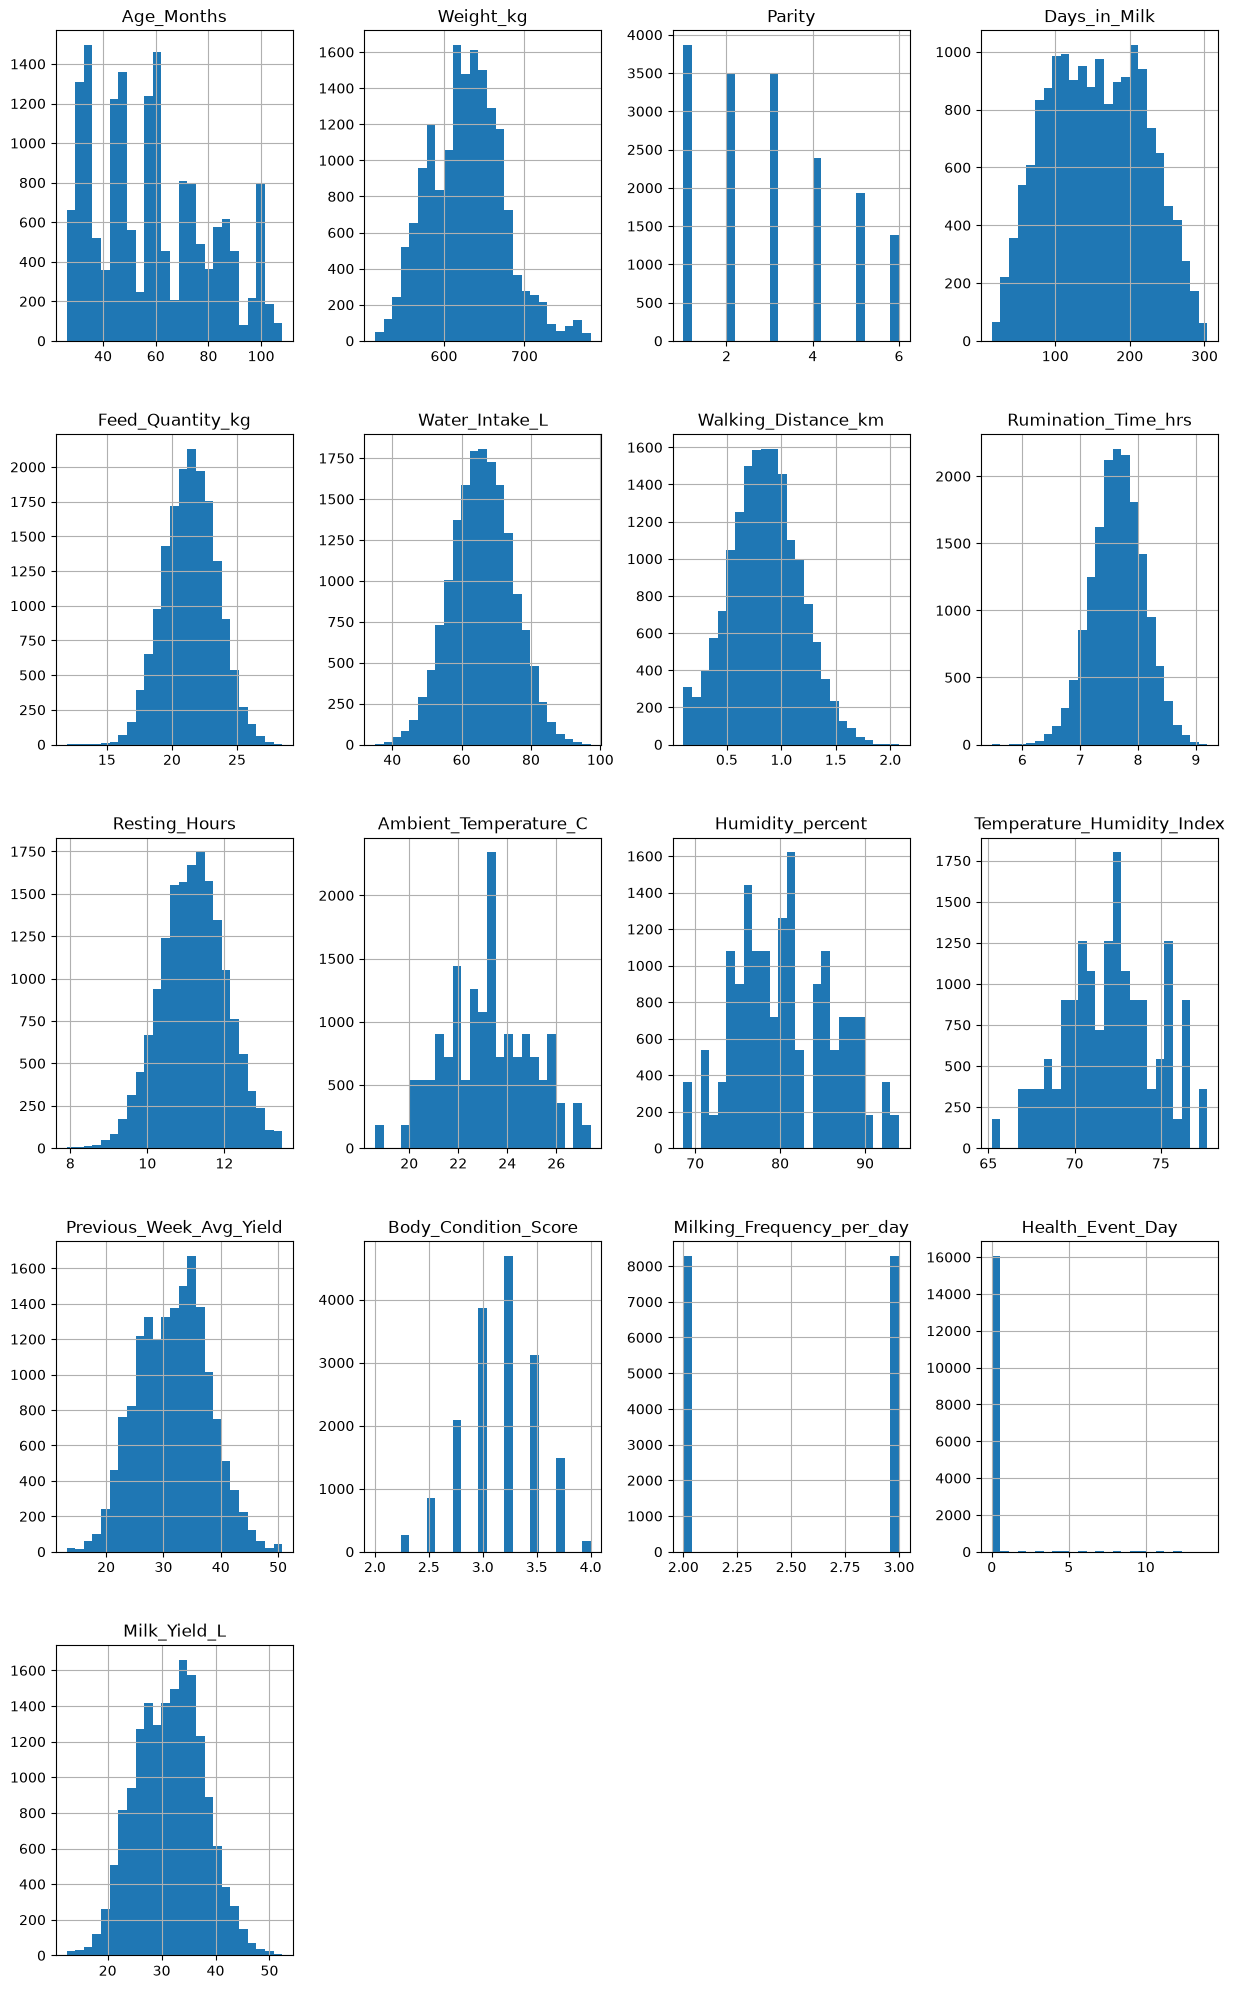

In [12]:
num_atributos.hist(bins = 25, figsize=(15,25))

#### Variáveis Categóricas

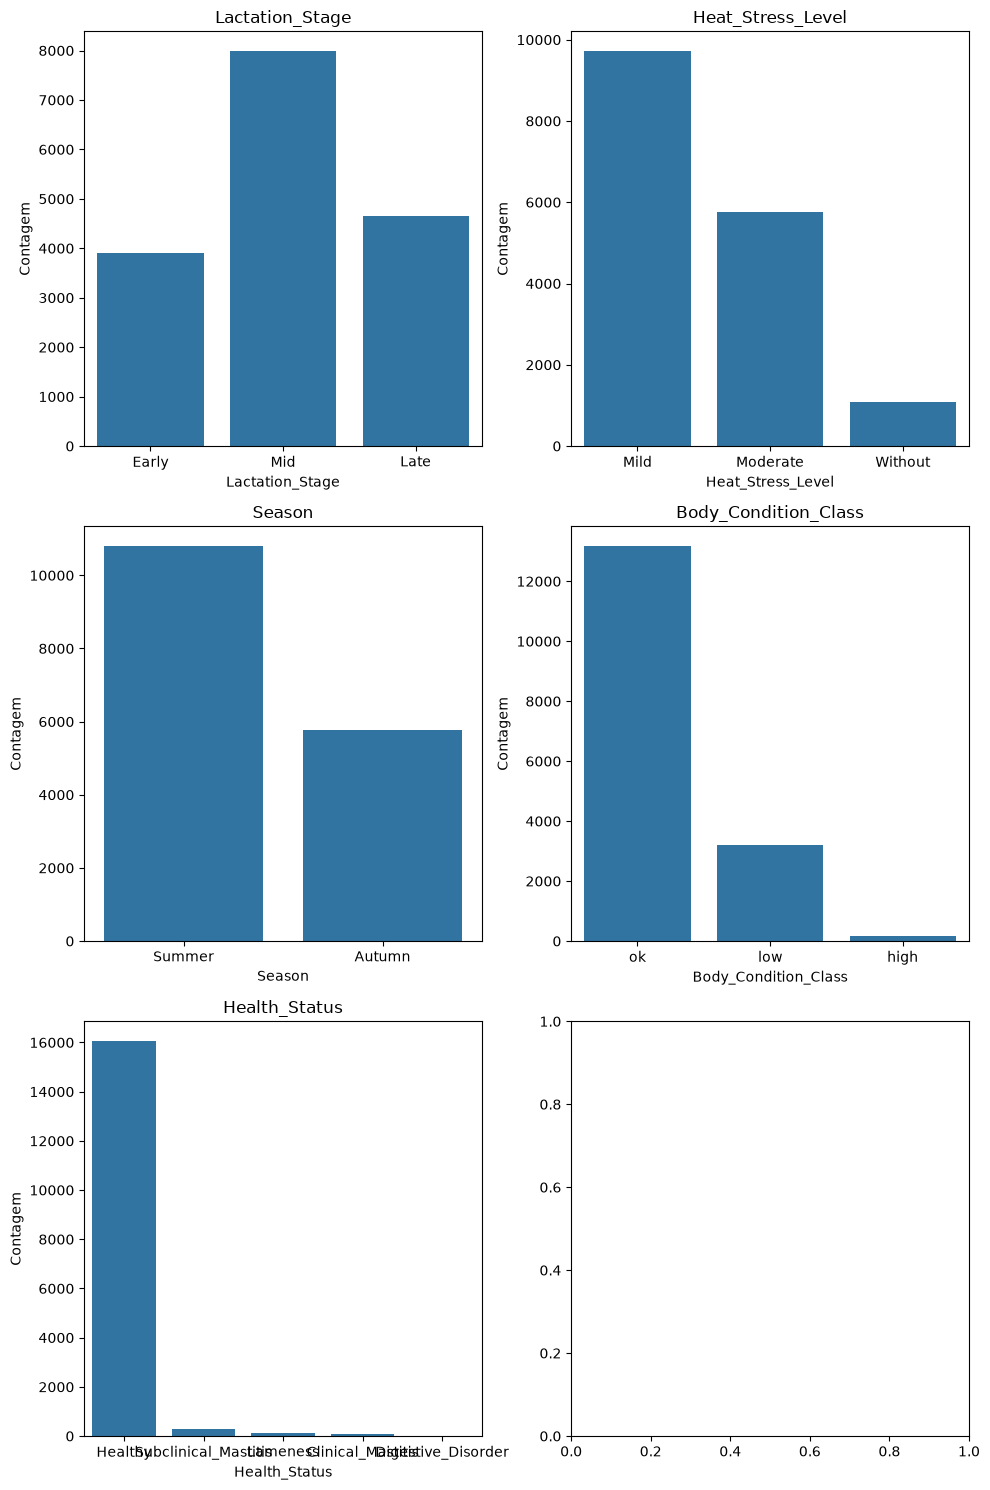

In [13]:
columns = ['Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status']

fig, axes = plt.subplots(3, 2, figsize = (10, 15))

for ax, columns in zip(axes.flat, columns):
    sns.countplot(data = cat_atributos, x = columns, ax = ax)
    ax.set_title(columns)
    ax.set_xlabel(columns)
    ax.set_ylabel('Contagem')

plt.tight_layout()
plt.show()

### Análise Bivariada

<Axes: xlabel='Lactation_Stage', ylabel='Media_Leite'>

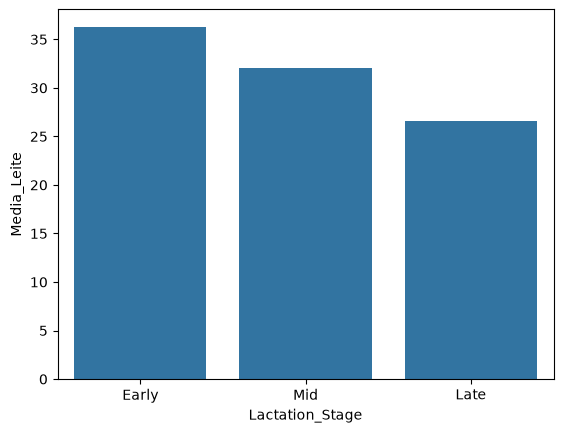

In [14]:
# 1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio

aux = df2.groupby('Lactation_Stage')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Lactation_Stage', y='Media_Leite')


<Axes: xlabel='Age_Months', ylabel='Media_Leite'>

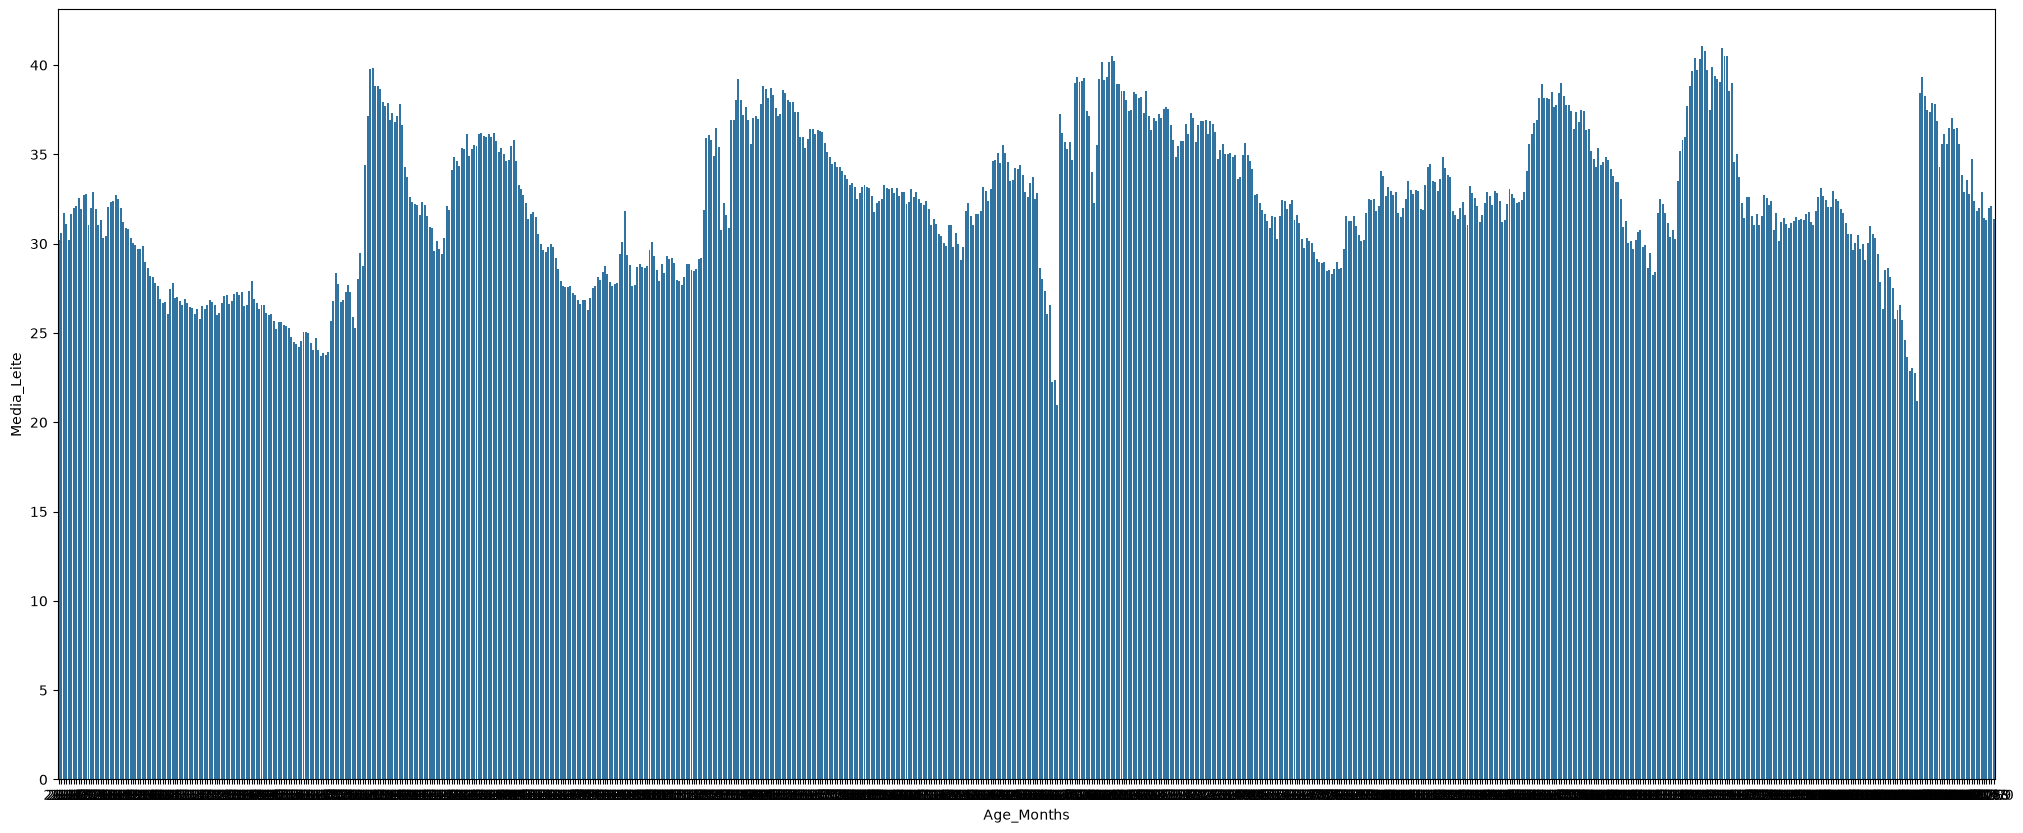

In [15]:
# 2. Vacas com idade mediana produz mais leite que as demais faixas de idade

aux = df2.groupby('Age_Months')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Age_Months', y='Media_Leite')

<Axes: xlabel='Weight_kg', ylabel='Media_Leite'>

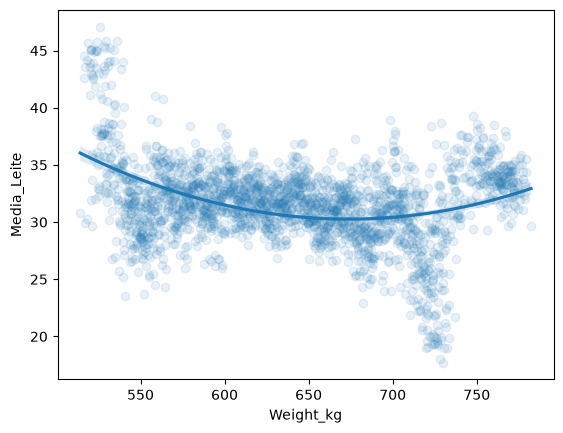

In [ ]:
# 3. Vacas mais pesadas tendem a produzir mais leite

aux = df2.groupby('Weight_kg')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Weight_kg', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Parity', ylabel='Media_Leite'>

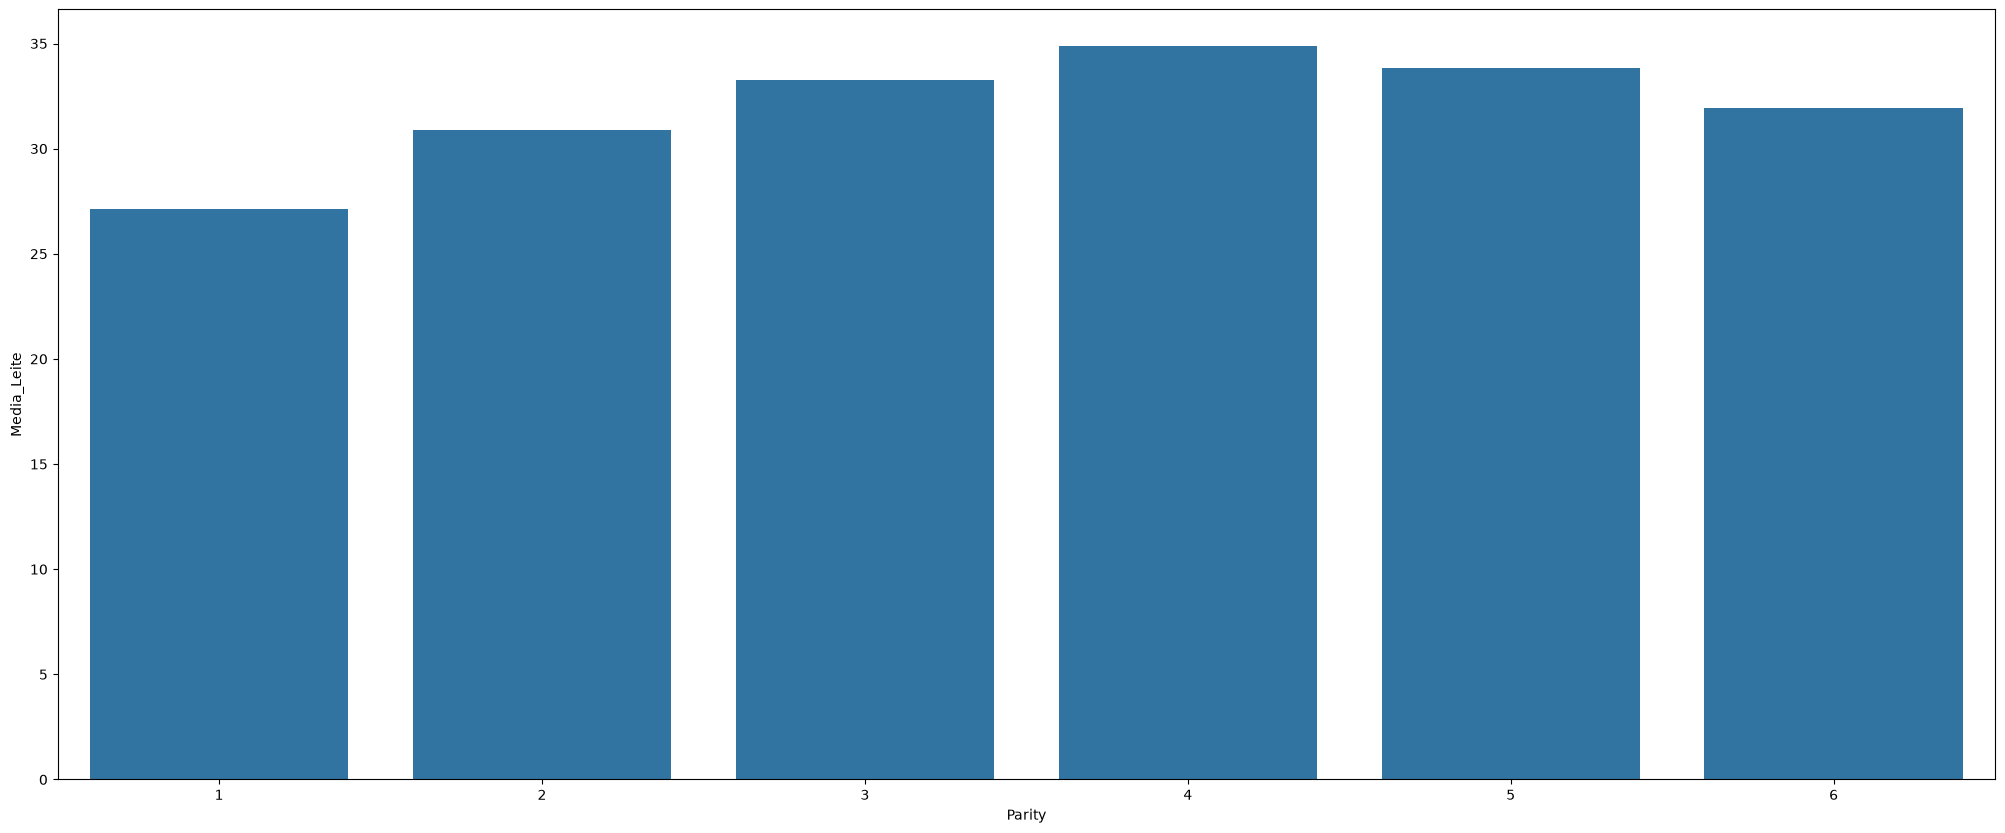

In [17]:
# 4. Vacas com número de partos mediano produz mais leite que as demais faixas de numero de partos

aux = df2.groupby('Parity')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Parity', y='Media_Leite')


<Axes: xlabel='Water_Intake_L', ylabel='Media_Leite'>

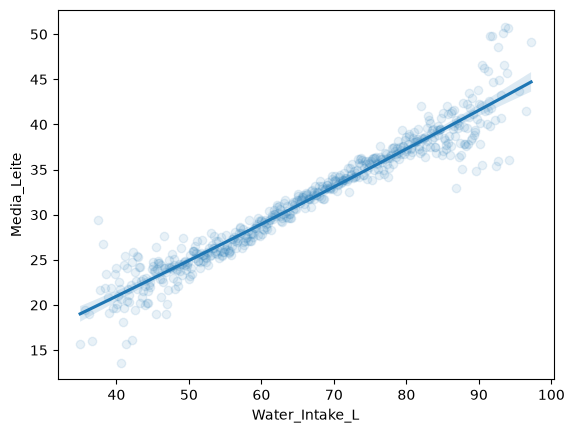

In [ ]:
# 5. Vacas que ingerem mais águas produzem mais litros leite diários

aux = df2.groupby('Water_Intake_L')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Water_Intake_L', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Walking_Distance_km', ylabel='Media_Leite'>

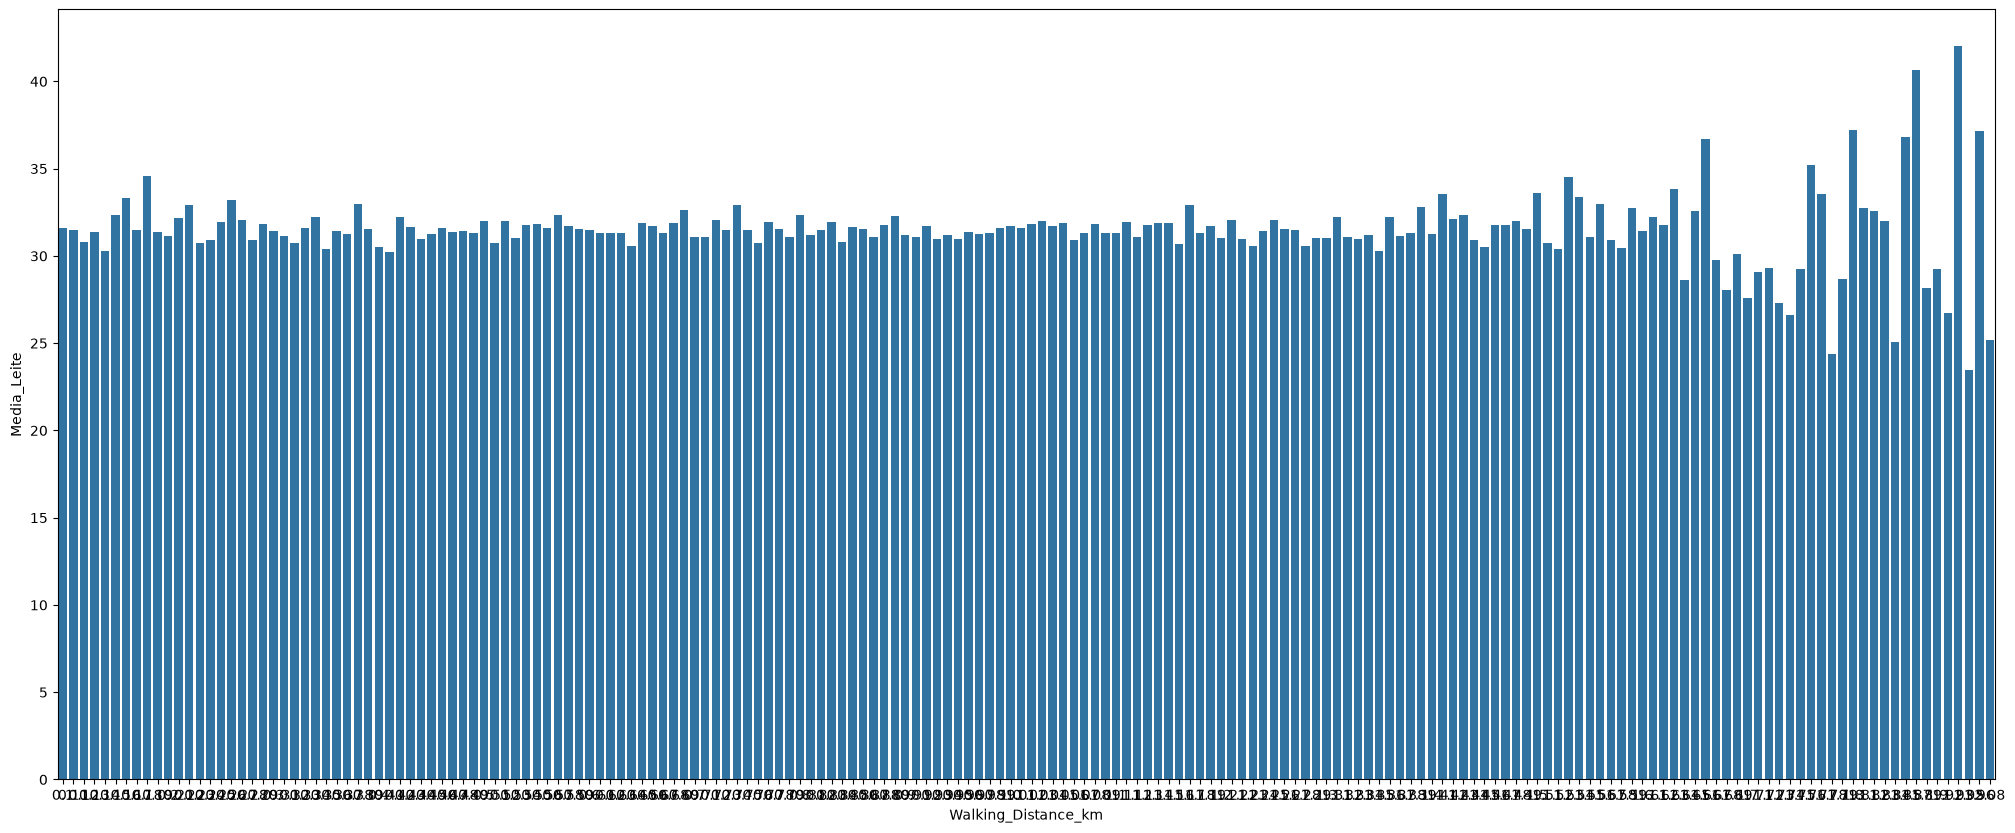

In [19]:
# 6. Vacas que andam mais, produzem menos litros de leite diários

aux = df2.groupby('Walking_Distance_km')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Walking_Distance_km', y='Media_Leite')

<Axes: xlabel='Resting_Hours', ylabel='Media_Leite'>

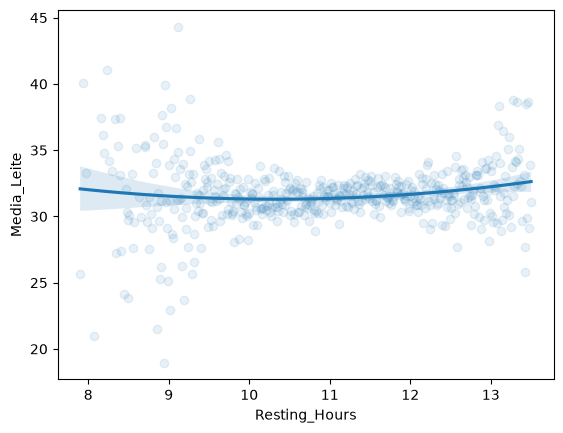

In [ ]:
# 7. Vacas que descansam mais tem mais produtividade litros de leite diários

aux = df2.groupby('Resting_Hours')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Resting_Hours', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})


Season
Summer    10800
Autumn     5760
Name: count, dtype: int64

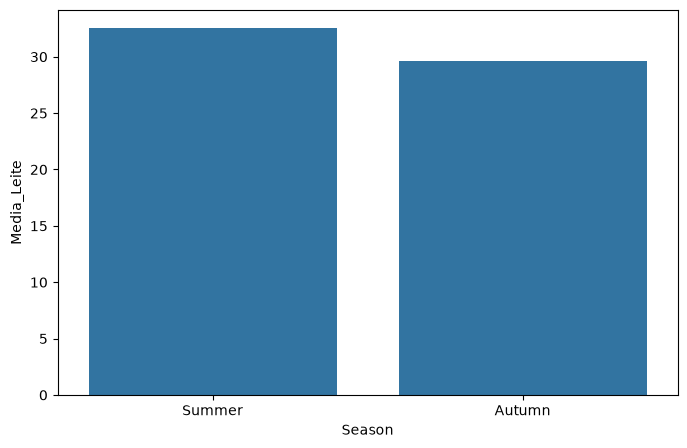

In [34]:
# 8. Vacas no outono produzem mais litros de leite diariamente

aux = df2.groupby('Season')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Season', y='Media_Leite')

df2['Season'].value_counts()

<Axes: xlabel='Previous_Week_Avg_Yield', ylabel='Milk_Yield_L'>

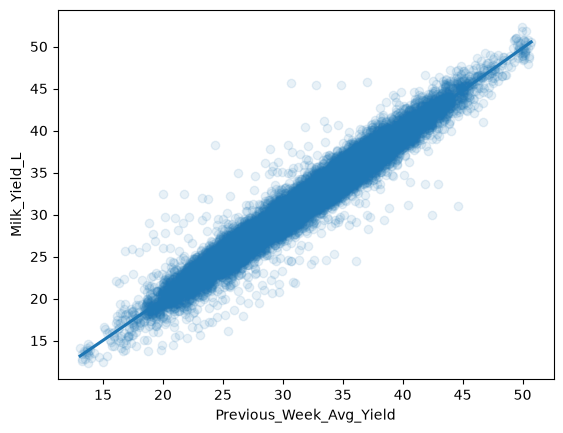

In [ ]:
# 9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite

sns.regplot(data=df2, x='Previous_Week_Avg_Yield', y='Milk_Yield_L', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Body_Condition_Score', ylabel='Media_Leite'>

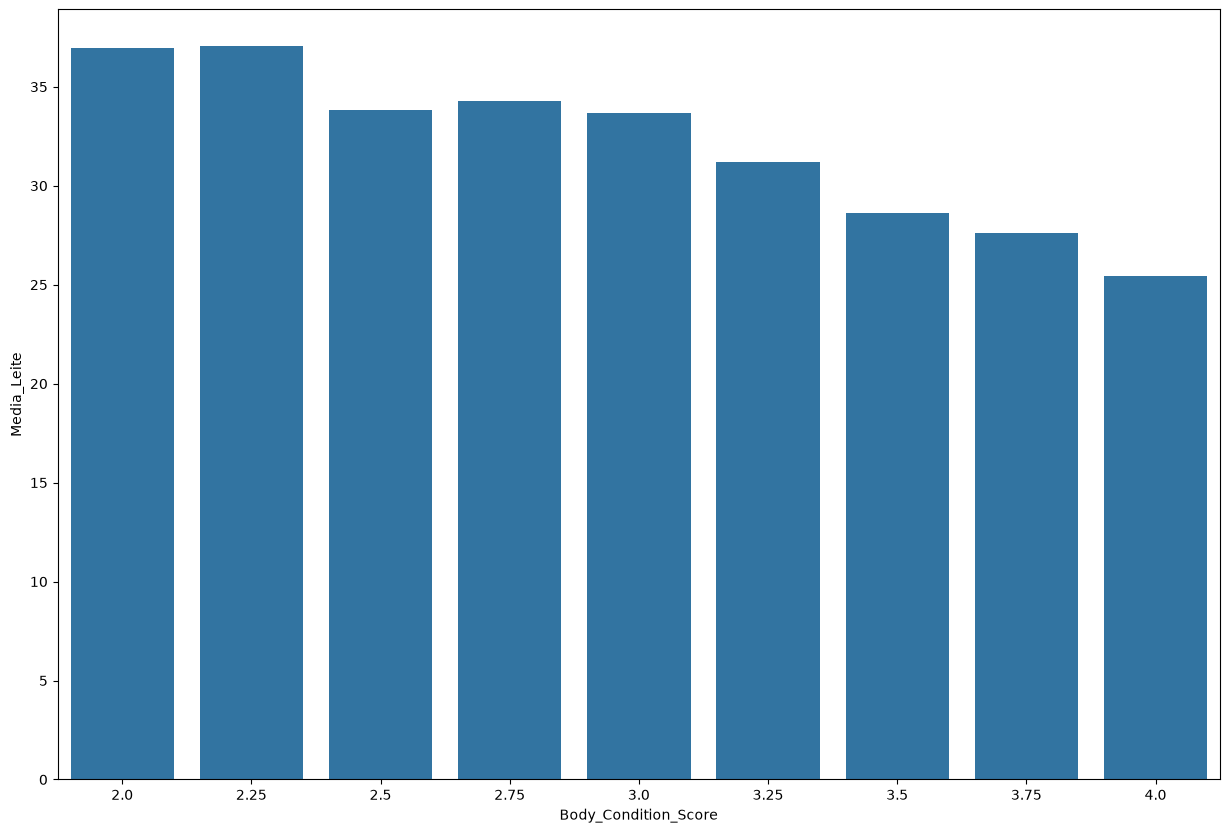

In [38]:
# 10. Vacas com score corporal 3 tendem a ter maior produtividade diária

aux = df2.groupby('Body_Condition_Score')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(15, 10))
sns.barplot(data=aux, x='Body_Condition_Score', y='Media_Leite')

<Axes: xlabel='Milking_Frequency_per_day', ylabel='Media_Leite'>

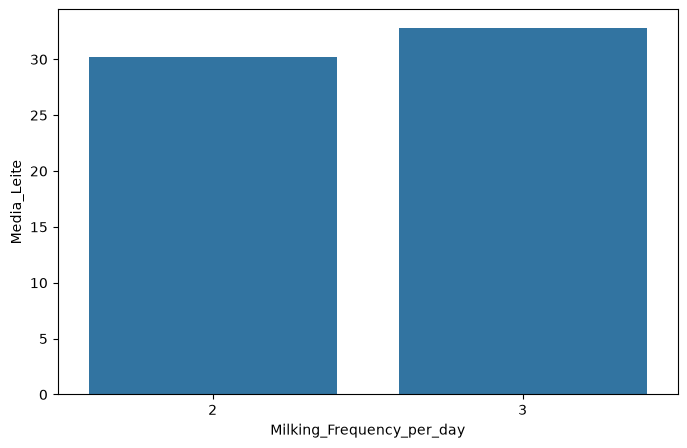

In [42]:
# 11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária

aux = df2.groupby('Milking_Frequency_per_day')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Milking_Frequency_per_day', y='Media_Leite')


<Axes: xlabel='Health_Status', ylabel='Media_Leite'>

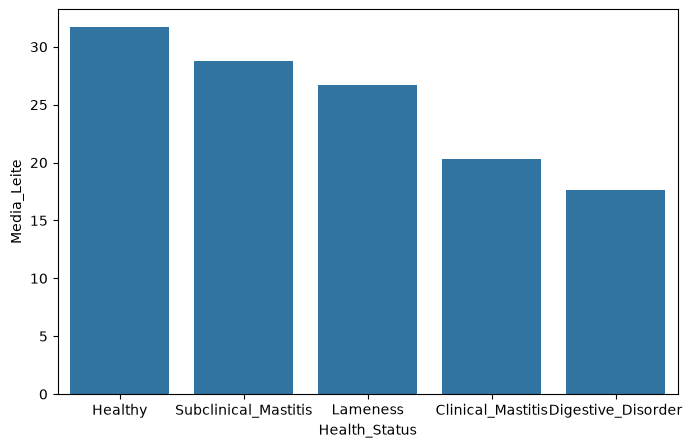

In [44]:
# 12. Vacas saudáveis tendem a produzir mais litros de leite 

aux = df2.groupby('Health_Status')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Health_Status', y='Media_Leite')

In [36]:
df2.columns

Index(['Cattle_ID', 'Age_Months', 'Weight_kg', 'Parity', 'Lactation_Stage',
       'Days_in_Milk', 'Feed_Quantity_kg', 'Water_Intake_L',
       'Walking_Distance_km', 'Rumination_Time_hrs', 'Resting_Hours',
       'Ambient_Temperature_C', 'Humidity_percent',
       'Temperature_Humidity_Index', 'Heat_Stress_Level', 'Season',
       'Previous_Week_Avg_Yield', 'Body_Condition_Score',
       'Body_Condition_Class', 'Milking_Frequency_per_day', 'Health_Status',
       'Health_Event_Day', 'Date', 'Milk_Yield_L'],
      dtype='str')

1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio: Falso. Cedo tem maior produtividade.
2. Vacas com idade mediana produzem mais litros de leite que as demais faixas de idade: Falso. Inconclusivo.
3. Vacas mais pesadas tendem a produzir mais leite: Falso. Inconclusivo.
4. Vacas com número de partos mediano produzem mais litros de leite que as demais faixas de numero de partos: Verdadeiro
5. Vacas que ingerem mais águas produzem mais litros leite diários: Verdadeiro
6. Vacas que andam mais, produzem menos litros de leite diários: Falso. Inconclusivo.
7. Vacas que descansam mais tem mais produtividade litros de leite diários: Falso. Inconclusivo.
8. Vacas no outono produzem mais litros de leite diariamente: Falso. No verão produz mais. 
9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite. Verdadeiro
10. Vacas com score corporal 3 tendem a ter maior produtividade diária. Falso. Entre 2 e 2.5 tendem a ter maior produtividade.
11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária: Verdadeiro.
12. Vacas saudáveis tendem a produzir mais litros de leite: Verdadeiro.

In [47]:
resultados = pd.DataFrame({
    'Hipoteses': [i for i in range(1, 13)],
    'Avaliacao': ['F', 'F', 'F', 'V', 'V', 'F', 'F', 'F', 'V', 'F', 'V', 'V']
})

resultados

,Hipoteses,Avaliacao
0,1,F
1,2,F
2,3,F
3,4,V
4,5,V
5,6,F
6,7,F
7,8,F
8,9,V
9,10,F


### Análise Multivariada

#### Variáveis Numéricas

<Axes: >

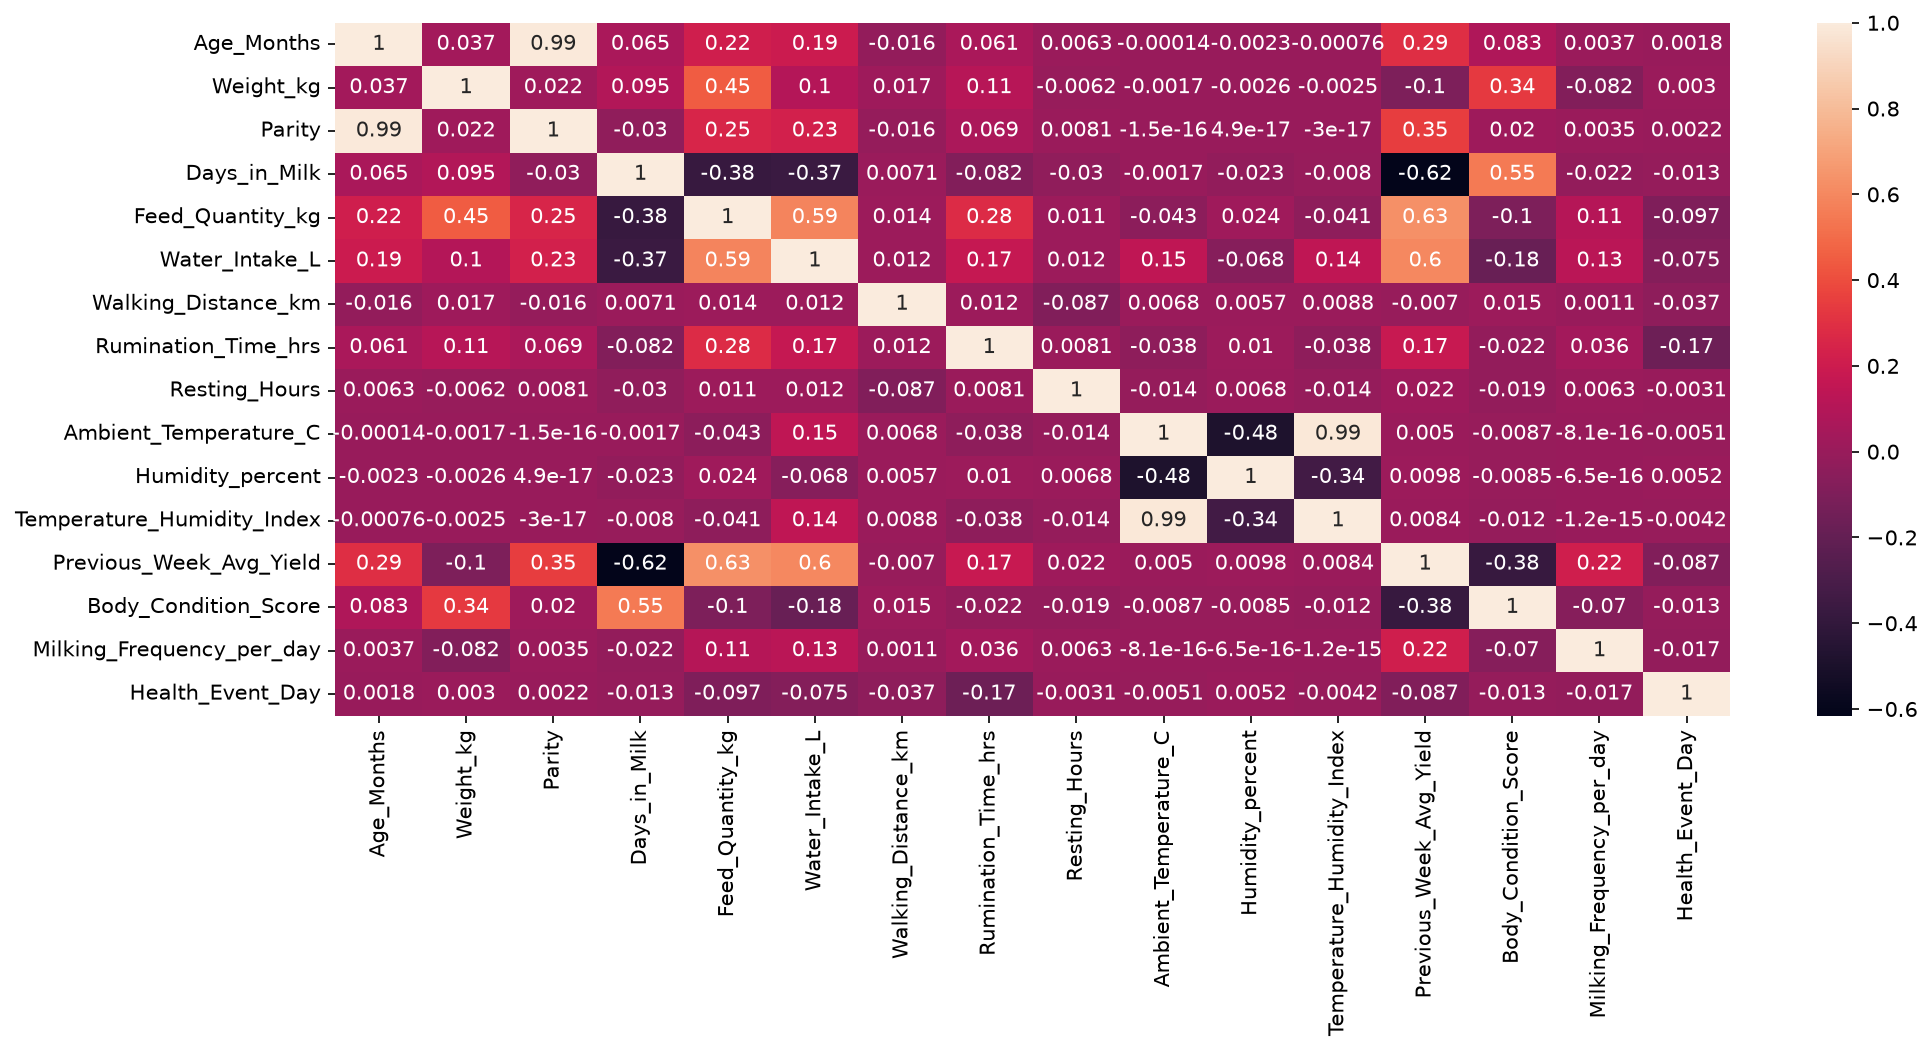

In [78]:
num_atributos_2 = num_atributos.drop(['Milk_Yield_L'], axis=1)

correlation_matrix = num_atributos_2.corr(method='pearson')

plt.figure(figsize=(15, 6), dpi=150)
sns.heatmap(correlation_matrix, annot=True)

#### Variáveis Categóricas

In [70]:

cat_atributos.columns


Index(['Cattle_ID', 'Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status'],
      dtype='str')

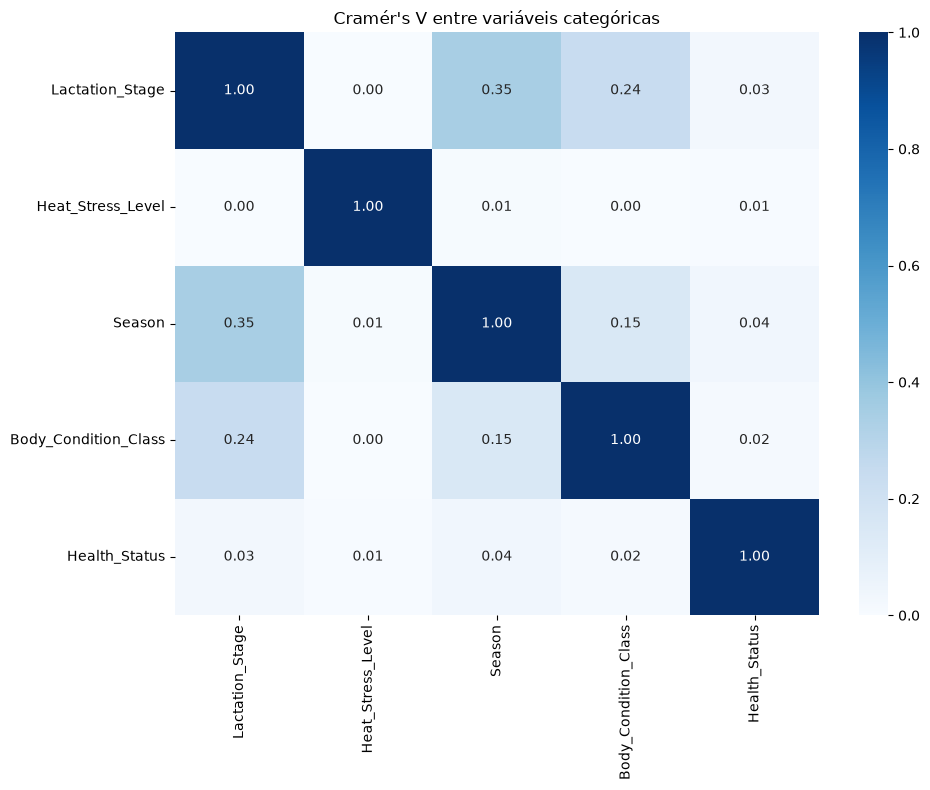

In [82]:
cat_cols = ['Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status']

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramer_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title("Cramér's V entre variáveis categóricas")
plt.tight_layout()
plt.show()

# Preparação de Dados

In [21]:
# columns = ['Breed', 'Climate_Zone', 'Management_System',
#        'Lactation_Stage', 'Feed_Type', 'Season', 'FMD_Vaccine',
#        'Brucellosis_Vaccine']

# fig, axes = plt.subplots(4, 2, figsize = (10, 15))

# for ax, columns in zip(axes.flat, columns):
#     sns.countplot(data = cat_atributos, x = columns, ax = ax)
#     ax.set_title(columns)
#     ax.set_xlabel('')
#     ax.set_ylabel('Quantidade')

# plt.tight_layout()
# plt.show()